/tmp/ipykernel_897/3047679632.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, patch_artist=True, labels=categories)


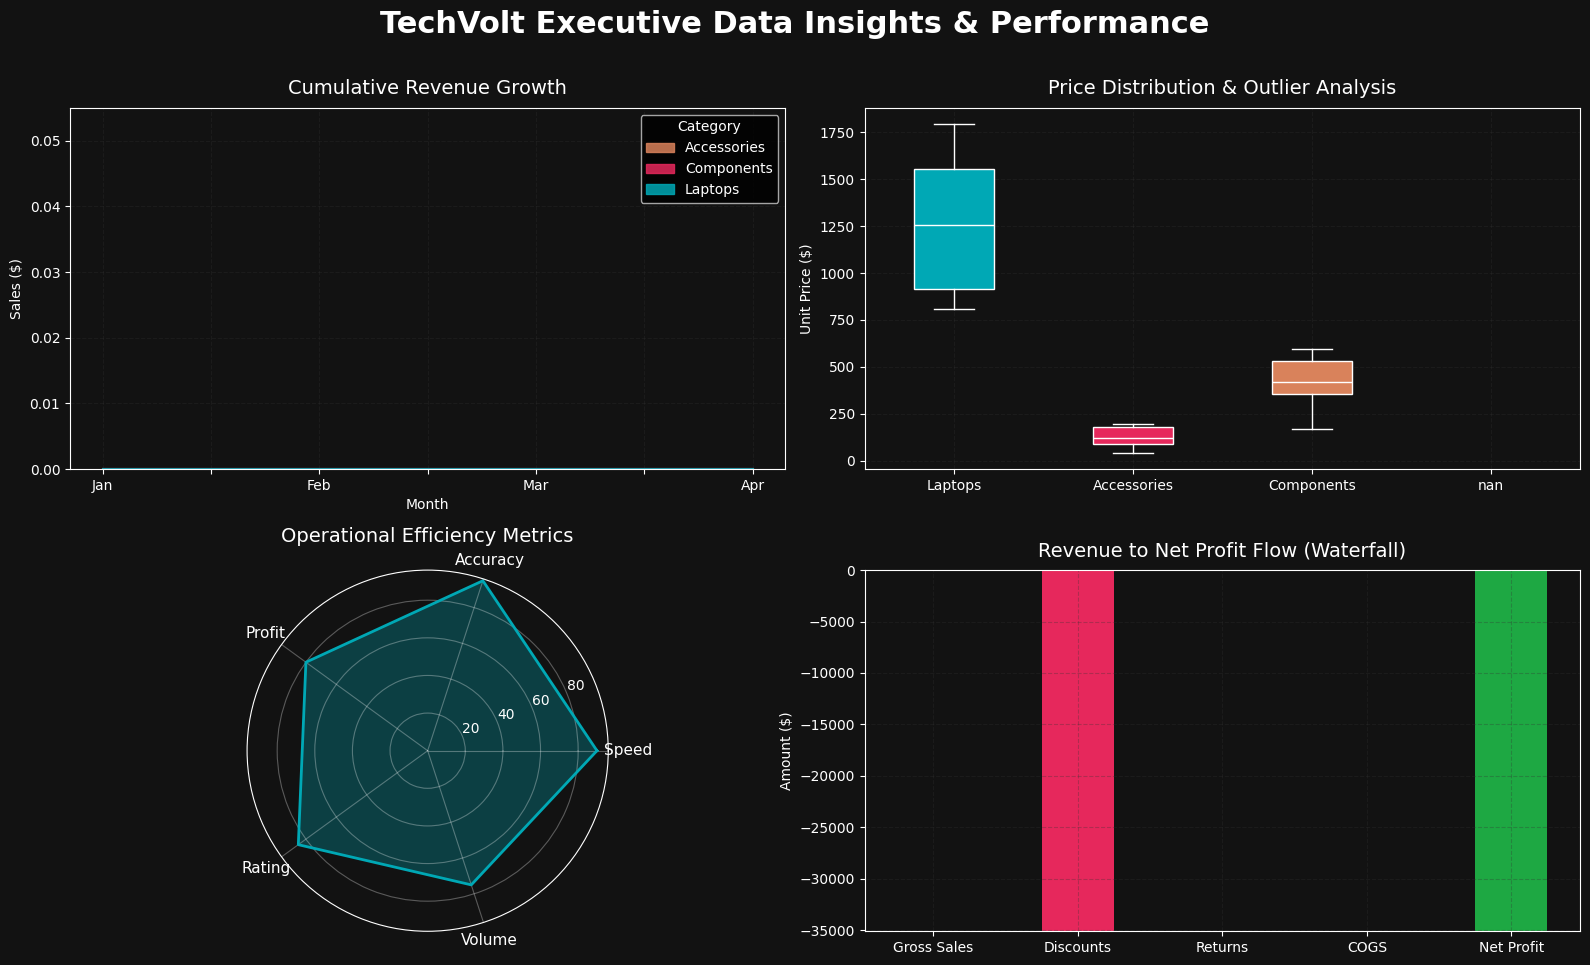

Process completed successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load source dataset
df = pd.read_excel('TechVolt_Sales_Dataset_100Rows.xlsx')

# Basic data cleaning and formatting
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])
df.to_csv('cleaned_sales_100rows.csv', index=False)

# Theme setup
plt.style.use('dark_background')
bg_color = '#121212'
grid_color = '#333333'
text_color = '#ffffff'

color_teal = '#00a8b5'
color_pink = '#e6285c'
color_orange = '#d9825b'
color_green = '#1ea843'

fig, axs = plt.subplots(2, 2, figsize=(16, 10), facecolor=bg_color)
fig.suptitle('TechVolt Executive Data Insights & Performance', fontsize=22, fontweight='bold', color=text_color, y=0.96)

# Chart 1: Revenue trend by category
df['Month'] = df['Date'].dt.strftime('%b')
monthly_sales = df.groupby(['Month', 'Category'])['Total Sales ($)'].sum().unstack().fillna(0)
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales = monthly_sales.reindex([m for m in months_order if m in monthly_sales.index])

ax1 = axs[0, 0]
ax1.set_facecolor(bg_color)
if not monthly_sales.empty:
    monthly_sales.plot(kind='area', stacked=True, ax=ax1, color=[color_orange, color_pink, color_teal], alpha=0.85)
ax1.set_title('Cumulative Revenue Growth', color=text_color, fontsize=14, pad=10)
ax1.set_ylabel('Sales ($)', color=text_color)
ax1.grid(True, linestyle='--', alpha=0.3, color=grid_color)

# Chart 2: Unit price spread
ax2 = axs[0, 1]
ax2.set_facecolor(bg_color)
categories = df['Category'].unique()
data_to_plot = [df[df['Category'] == cat]['Unit Price ($)'] for cat in categories]

bp = ax2.boxplot(data_to_plot, patch_artist=True, labels=categories)
colors = [color_teal, color_pink, color_orange]
for patch, color in zip(bp['boxes'], colors[:len(categories)]):
    patch.set_facecolor(color)
    patch.set_edgecolor('white')

for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bp[element], color='white')

ax2.set_title('Price Distribution & Outlier Analysis', color=text_color, fontsize=14, pad=10)
ax2.set_ylabel('Unit Price ($)', color=text_color)
ax2.grid(True, linestyle='--', alpha=0.3, color=grid_color)

# Chart 3: KPI Radar
axs[1, 0].remove()
ax3 = fig.add_subplot(2, 2, 3, polar=True)
ax3.set_facecolor(bg_color)
labels = ['Speed', 'Accuracy', 'Profit', 'Rating', 'Volume']
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
values = [90, 95, 80, 85, 75]
values += values[:1]

ax3.plot(angles, values, color=color_teal, linewidth=2)
ax3.fill(angles, values, color=color_teal, alpha=0.3)
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(labels, color=text_color, fontsize=11)
ax3.set_title('Operational Efficiency Metrics', color=text_color, fontsize=14, pad=20)
ax3.grid(True, color='white', alpha=0.3)

# Chart 4: Net profit breakdown
ax4 = axs[1, 1]
ax4.set_facecolor(bg_color)
gross_sales = df['Total Sales ($)'].sum()
discounts = (df['Quantity'] * df['Unit Price ($)'] * df['Discount (%)']).sum()
returns = gross_sales * 0.05
cogs = gross_sales * 0.45
net_profit = gross_sales - discounts - returns - cogs

labels_wf = ['Gross Sales', 'Discounts', 'Returns', 'COGS', 'Net Profit']
heights = [gross_sales, discounts, returns, cogs, net_profit]
bottoms = [0, gross_sales - discounts, gross_sales - discounts - returns, net_profit, 0]
colors_wf = [color_teal, color_pink, color_pink, color_pink, color_green]

ax4.bar(labels_wf, heights, bottom=bottoms, color=colors_wf, width=0.5)
ax4.set_title('Revenue to Net Profit Flow (Waterfall)', color=text_color, fontsize=14, pad=10)
ax4.set_ylabel('Amount ($)', color=text_color)
ax4.grid(True, linestyle='--', alpha=0.3, color=grid_color)

# Render and save figure
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('dashboard.png', dpi=300, facecolor=bg_color)
plt.show()

print("Process completed successfully.")